In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from scipy.stats import norm

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [2]:
BASE_PATH = Path("../data/processed/new_processed")

REPORT_PATH = Path("../reports")
CHART_PATH = REPORT_PATH / "python_charts"

CHART_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
funds = pd.read_csv(
    BASE_PATH / "clean_fund_master.csv"
)

nav = pd.read_csv(
    BASE_PATH / "clean_nav_history.csv",
    parse_dates=["date"]
)

transactions = pd.read_csv(
    BASE_PATH / "clean_transactions.csv",
    parse_dates=["transaction_date"]
)

performance = pd.read_csv(
    BASE_PATH / "final_performance_metrics.csv"
)

print(nav.shape)
print(transactions.shape)

(46000, 3)
(32778, 13)


In [4]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [5]:
confidence = 0.95

var_results = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 50:
        continue

    var95 = np.percentile(
        returns,
        (1-confidence)*100
    )

    var_results.append(
        [code,var95]
    )

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [6]:
var_df.to_csv(
    BASE_PATH / "value_at_risk.csv",
    index=False
)

In [7]:
risk_return = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 50:
        continue

    annual_return = (
        returns.mean()*252
    )

    annual_risk = (
        returns.std()*np.sqrt(252)
    )

    risk_return.append(
        [code,
         annual_return,
         annual_risk]
    )

risk_return = pd.DataFrame(
    risk_return,
    columns=[
        "amfi_code",
        "return",
        "risk"
    ]
)

risk_return.head()

,amfi_code,return,risk
0,100016,0.035683,0.145481
1,100025,0.042854,0.039052
2,100033,0.272111,0.189367
3,101206,0.214647,0.145682
4,101207,0.106962,0.257973


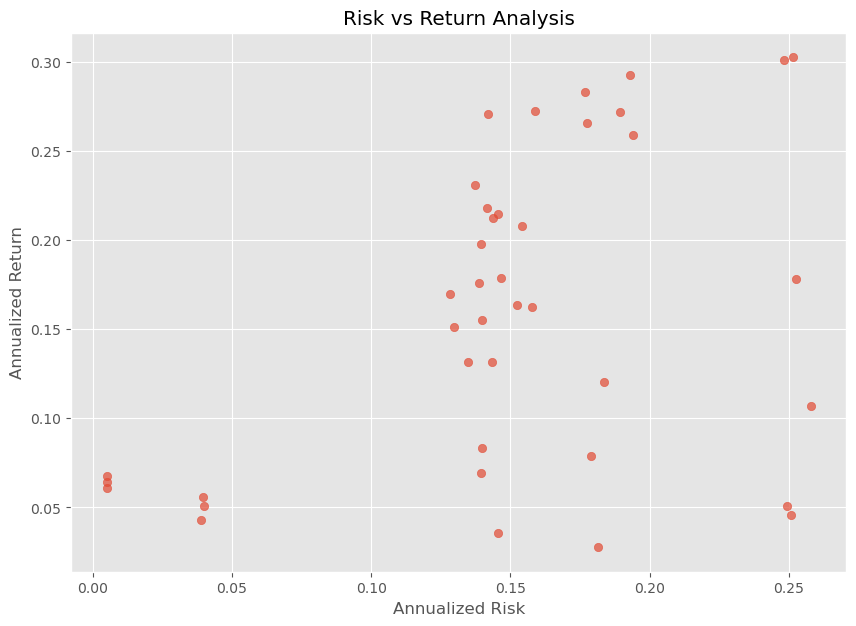

In [8]:
plt.figure(figsize=(10,7))

plt.scatter(
    risk_return["risk"],
    risk_return["return"],
    alpha=0.7
)

plt.title(
    "Risk vs Return Analysis"
)

plt.xlabel("Annualized Risk")
plt.ylabel("Annualized Return")

plt.savefig(
    CHART_PATH /
    "risk_return_scatter.png",
    dpi=300
)

plt.show()

In [9]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [10]:
investor_summary = (
    transactions
    .groupby("investor_id")
    .agg({
        "amount_inr":"sum"
    })
    .reset_index()
)

investor_summary.head()

,investor_id,amount_inr
0,INV000001,237429
1,INV000002,681325
2,INV000003,17861
3,INV000004,476881
4,INV000005,1398173


In [11]:
scaler = StandardScaler()

scaled = scaler.fit_transform(
    investor_summary[
        ["amount_inr"]
    ]
)

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

investor_summary["segment"] = (
    kmeans.fit_predict(
        scaled
    )
)

investor_summary.head()

,investor_id,amount_inr,segment
0,INV000001,237429,0
1,INV000002,681325,2
2,INV000003,17861,0
3,INV000004,476881,0
4,INV000005,1398173,1


In [13]:
segment_stats = (
    investor_summary
    .groupby("segment")
    ["amount_inr"]
    .mean()
)

segment_stats

segment
0    2.353409e+05
1    1.551463e+06
2    8.235612e+05
Name: amount_inr, dtype: float64

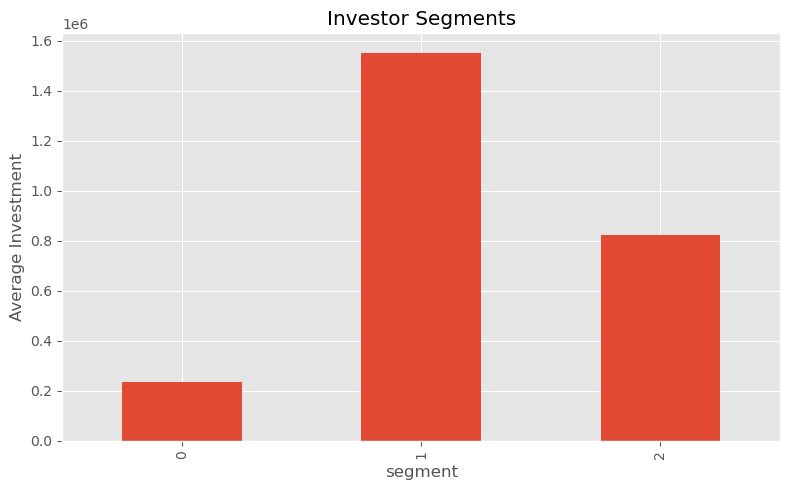

In [14]:
segment_stats.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Investor Segments"
)

plt.ylabel(
    "Average Investment"
)

plt.tight_layout()

plt.savefig(
    CHART_PATH /
    "investor_segments.png",
    dpi=300
)

plt.show()

In [15]:
transactions["month"] = (
    transactions[
        "transaction_date"
    ].dt.to_period("M")
)

In [16]:
cohort = (
    transactions
    .groupby("month")
    .agg(
        investors=(
            "investor_id",
            "nunique"
        )
    )
)

cohort.head()

,investors
month,
2024-01,1577
2024-02,1530
2024-03,1592
2024-04,1558
2024-05,1551


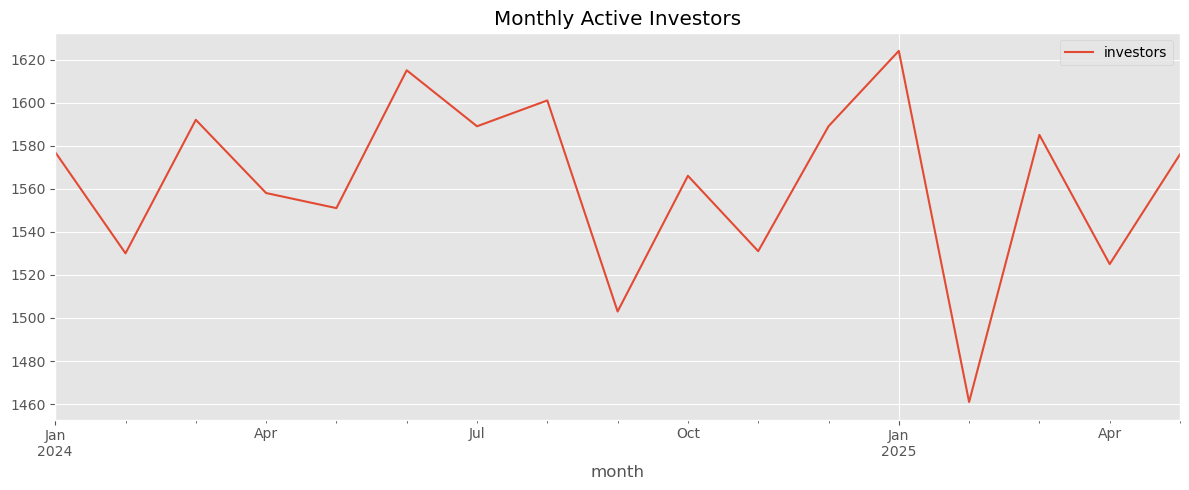

In [17]:
cohort.plot(
    figsize=(12,5)
)

plt.title(
    "Monthly Active Investors"
)

plt.tight_layout()

plt.savefig(
    CHART_PATH /
    "monthly_investors.png",
    dpi=300
)

plt.show()

In [18]:
sip_txn = transactions[
    transactions[
        "transaction_type"
    ]=="SIP"
]

In [19]:
sip_monthly = (
    sip_txn
    .groupby("month")
    ["amount_inr"]
    .sum()
)

sip_monthly.head()

month
2024-01    12635349
2024-02    12613376
2024-03    12088413
2024-04    13512385
2024-05    13218606
Freq: M, Name: amount_inr, dtype: int64

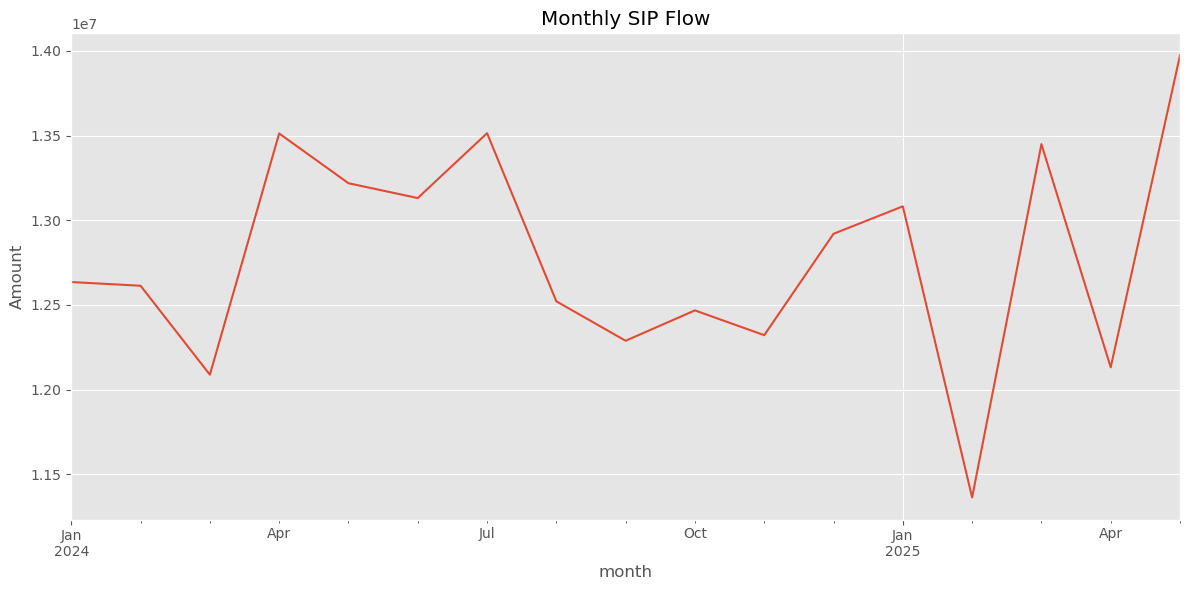

In [20]:
sip_monthly.plot(
    figsize=(12,6)
)

plt.title(
    "Monthly SIP Flow"
)

plt.ylabel("Amount")

plt.tight_layout()

plt.savefig(
    CHART_PATH /
    "sip_monthly_flow.png",
    dpi=300
)

plt.show()

In [21]:
state_analysis = (
    transactions
    .groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

state_analysis

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

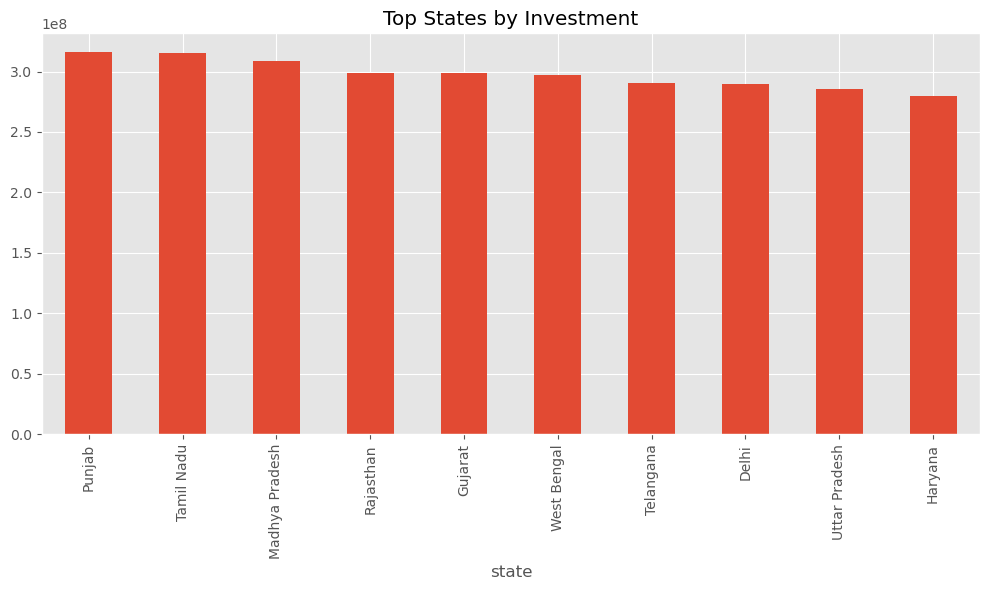

In [22]:
state_analysis.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Top States by Investment"
)

plt.tight_layout()

plt.savefig(
    CHART_PATH /
    "top_states.png",
    dpi=300
)

plt.show()

In [23]:
top_funds = (
    transactions
    .groupby("amfi_code")
    ["amount_inr"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_funds

amfi_code
102885    100374918
148568     99482585
119094     97384474
119095     96970660
119551     95041213
120506     93475766
101208     92931528
118636     92903919
102886     92430980
100025     92212042
Name: amount_inr, dtype: int64

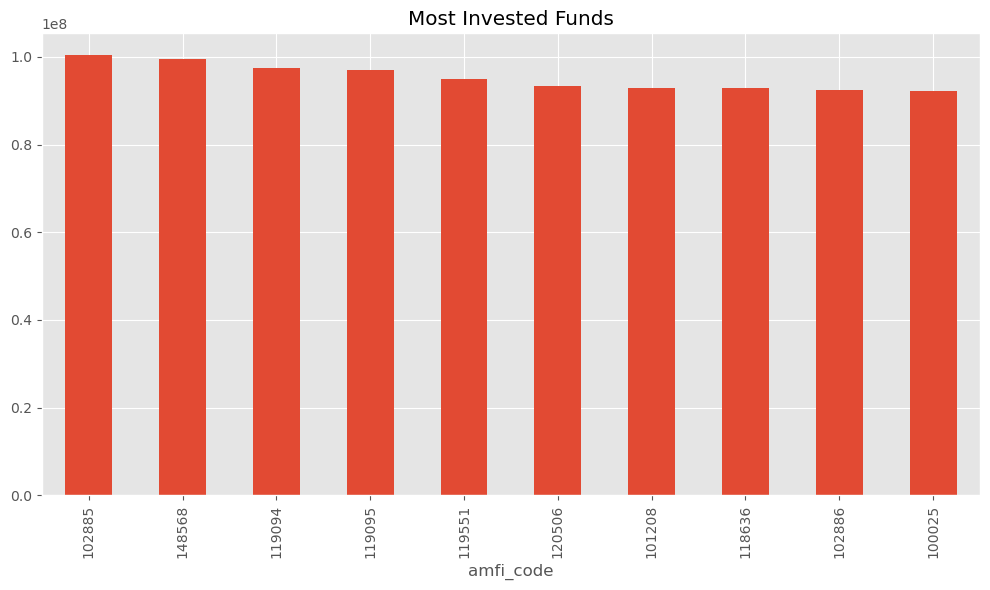

In [24]:
top_funds.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Most Invested Funds"
)

plt.tight_layout()

plt.savefig(
    CHART_PATH /
    "most_invested_funds.png",
    dpi=300
)

plt.show()

In [25]:
advanced_report = (
    performance
    .merge(
        var_df,
        on="amfi_code",
        how="left"
    )
)

In [26]:
advanced_report.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,...,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,VaR_95
0,148567,0.145807,0.312786,NaN,1.448291,0.269107,0.010472,-0.112657,4.0,1.0,...,2008-04-04,NIFTY 100 TRI,1.46,1.0,500,1000,Gaurav Misra,Moderate,EC01,-0.013560
1,120843,0.284811,0.256619,NaN,1.306744,0.273211,-0.004370,-0.129740,10.0,2.0,...,2009-08-11,NIFTY 500 TRI,1.45,1.0,500,1000,Pankaj Tibrewal,Moderately High,EC04,-0.014508
2,101206,0.450939,0.325286,NaN,1.027213,0.214656,-0.000067,-0.112916,3.0,9.0,...,2002-08-30,NIFTY 100 TRI,1.60,1.0,500,1000,Mahesh Patil,Moderate,EC01,-0.013282
3,100033,0.477346,0.336292,NaN,1.093699,0.268752,0.024097,-0.162172,2.0,7.0,...,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02,-0.019034
4,120504,0.115007,0.283698,NaN,1.026524,0.216091,-0.026139,-0.125883,6.0,10.0,...,2013-01-01,NIFTY 100 TRI,0.80,1.0,500,1000,Anish Tawakley,Moderate,EC01,-0.013728


In [27]:
print("="*50)
print("ADVANCED ANALYTICS COMPLETED")
print("="*50)

print("Files Generated:")

print("value_at_risk.csv")
print("advanced_analytics_report.csv")

print("Charts Generated:")
print("risk_return_scatter.png")
print("investor_segments.png")
print("monthly_investors.png")
print("sip_monthly_flow.png")
print("top_states.png")
print("most_invested_funds.png")

ADVANCED ANALYTICS COMPLETED
Files Generated:
value_at_risk.csv
advanced_analytics_report.csv
Charts Generated:
risk_return_scatter.png
investor_segments.png
monthly_investors.png
sip_monthly_flow.png
top_states.png
most_invested_funds.png
